In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_community.document_loaders import PyPDFLoader
from langchain_openai import OpenAIEmbeddings

from typing import TypedDict, List, Annotated

from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import PyPDFLoader, WebBaseLoader

from langchain_openai import OpenAIEmbeddings
import os

from dotenv import load_dotenv
load_dotenv()

from langchain_community.vectorstores import FAISS

from langchain_openai import ChatOpenAI

from typing import TypedDict, List, Literal
from langchain_core.documents import Document


g:\ml\.venv\Lib\site-packages\langchain_core\utils\pydantic.py:42: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1 import BaseModel as BaseModelV1
g:\ml\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\User\AppData\Local\Temp\ipykernel_29760\1978803243.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [2]:
loader = WebBaseLoader("https://docs.langchain.com/oss/python/langgraph/agentic-rag#build-a-custom-rag-agent-with-langgraph")
data = loader.load()
data

[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/agentic-rag#build-a-custom-rag-agent-with-langgraph', 'title': 'Build a custom RAG agent with LangGraph - Docs by LangChain', 'description': 'Build a custom retrieval agent with LangGraph that decides when to search a vector store or respond directly.', 'language': 'en'}, page_content='Build a custom RAG agent with LangGraph - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what\'s next for agents. Get your tickets →Docs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraphBuild a custom RAG agent with LangGraphOverviewDeep AgentsManaged Deep AgentsLangChainLangGraphOpenWikiIntegrationsLearnReferenceContributePythonLearnTutorialsDeep 

In [3]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=900,
    chunk_overlap=100,
)

chunks = text_splitter.split_documents(data)
print(f"Number of chunks: {len(chunks)}")
chunks[0]

Number of chunks: 30


Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/agentic-rag#build-a-custom-rag-agent-with-langgraph', 'title': 'Build a custom RAG agent with LangGraph - Docs by LangChain', 'description': 'Build a custom retrieval agent with LangGraph that decides when to search a vector store or respond directly.', 'language': 'en'}, page_content="Build a custom RAG agent with LangGraph - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what's next for agents. Get your tickets →Docs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraphBuild a custom RAG agent with LangGraphOverviewDeep AgentsManaged Deep AgentsLangChainLangGraphOpenWikiIntegrationsLearnReferenceContributePythonLearnTutorialsDeep Ag

In [7]:
embeddings = OpenAIEmbeddings(
    api_key=os.environ["OPENROUTER_API_KEY"],
    base_url="https://openrouter.ai/api/v1" # OpenRouter base URL
)

In [6]:
from pinecone import Pinecone

from pinecone import ServerlessSpec

pc = Pinecone(api_key=os.getenv("PINECONE_DB"))

if not pc.has_index("agenticrag"):
    pc.create_index(name="agenticrag", dimension=1536, metric="cosine", spec=ServerlessSpec(cloud="aws", region="us-east-1"))


index = pc.Index("agenticrag")

In [8]:
from langchain_pinecone import PineconeVectorStore
vector_store_pine = PineconeVectorStore(index=index,embedding=embeddings)

In [9]:
vector_store_pine.add_documents(chunks)

['548a6563-72d3-44da-a811-5d871d2d5ec5',
 'e1c99575-2090-4ec8-8486-d7bf391f3c0c',
 '58069c6d-741d-4bda-b6a6-bf53aa0e7ba1',
 'd6c3b5a6-e922-4482-9745-612b076fd687',
 '678a6f0b-bdbe-4a01-931a-8087f12c2af6',
 'adab5f16-620a-486d-8ad0-45acfd58b9d0',
 '52b3789d-3174-4c48-aa4c-4bcdbdd92835',
 '42daf3e1-e886-48f8-8a3c-9f30a50948d4',
 '229d090f-1edb-4868-8ff8-5e91a0c592bf',
 '0e72e267-ee28-472b-a640-0968e053d29c',
 '45413580-7fd7-4616-95bd-954fbcf61242',
 'a947cb7e-0ca7-4f13-a9b9-e0174792f606',
 'a7917ea1-0bbf-4052-824f-0b00fdab84b0',
 '8440ea81-d9e5-4476-bdce-819d478382e6',
 'c81666ec-2ba3-4f95-a384-0b3e8d1d0cdd',
 '7cc98f19-91ee-4cde-87a1-7b2ac930bd33',
 '1f2229cc-47ab-4eba-9e87-66a368afaf2e',
 '3e91141c-a770-4177-ad04-d74a10cb5aa7',
 '7e4ca46b-74e4-4c62-b895-a8f77000b7fd',
 '0d35af74-2dad-43db-bba1-3c0b61743abb',
 'd652b3e7-be3d-4352-85a7-196db363ebd9',
 'f807c55f-ae69-4030-8c48-0629b63e5231',
 '75bb26c0-de4d-4546-9039-2f72323a0b63',
 '3b6cca38-6cbe-49d9-b120-9ce288b57982',
 '5ed42040-e5ad-

In [247]:
retriever = vector_store_pine.as_retriever(search_kwargs={"k": 6})
retriever

VectorStoreRetriever(tags=['PineconeVectorStore', 'OpenAIEmbeddings'], vectorstore=<langchain_pinecone.vectorstores.PineconeVectorStore object at 0x0000018502923380>, search_kwargs={'k': 6})

In [248]:
# index = pc.Index("agenticrag")

# vector_store = PineconeVectorStore(index=index, embedding=embeddings)


In [249]:
retriever.invoke("What is custom rag?")

[Document(id='548a6563-72d3-44da-a811-5d871d2d5ec5', metadata={'description': 'Build a custom retrieval agent with LangGraph that decides when to search a vector store or respond directly.', 'language': 'en', 'source': 'https://docs.langchain.com/oss/python/langgraph/agentic-rag#build-a-custom-rag-agent-with-langgraph', 'title': 'Build a custom RAG agent with LangGraph - Docs by LangChain'}, page_content="Build a custom RAG agent with LangGraph - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what's next for agents. Get your tickets →Docs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraphBuild a custom RAG agent with LangGraphOverviewDeep AgentsManaged Deep AgentsLangChainLangGraphOpenWikiIntegrationsLearnRe

In [250]:
llm = ChatOpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    model="openai/gpt-4o-mini"
)

In [251]:
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(
    max_results=3,
    topic="general",
    search_depth="advanced"
)

In [252]:
from typing import TypedDict, List, Dict, Any


class AgentState(TypedDict):
    question: str
    route: Literal["retriever", "websearch", "generate_answer"]
    context: List[Document]
    grade_kb: bool

    web_results: List[Dict[str, Any]]
    grade_web: bool

    generated_kb_answer: str
    generated_web_answer: str

    loops: int

    general_answer: str

    direct_answer_or_fallback_answer: str

    rewritten_question: str

## decider

In [253]:
from pydantic import BaseModel
from langchain_core.messages import SystemMessage, HumanMessage

class Decider(BaseModel):
    route: Literal["retriever", "websearch", "generate_answer"]

def decider_node(state: AgentState):
    question = state["question"]
    decider_llm = llm.with_structured_output(Decider)
    decider_value = decider_llm.invoke([
        SystemMessage(content="""
You are a routing classifier.

Choose exactly one route:

"retriever"
Use the local retriever when the question is likely answerable from the
indexed documentation about LangChain, LangGraph, custom RAG, retrieval,
grading, query rewriting, and related RAG workflow components.

"websearch"
Use web search when the question requires current, changing, recent, or
external information that is not expected to be in the local knowledge base.
Examples:
- latest versions
- recent releases
- current news
- newly added features

"generate_answer"
Use a direct answer when the question can be answered from general knowledge
and does not require the local knowledge base or current web information.

Do not answer the question.
Only choose the route.
"""),
        HumanMessage(content=question)
    ])

    print(f"Decider result: {decider_value.route}\n")

    return {"route": decider_value.route}

## Retrieval and gradeKB and generate answer

In [254]:
def retriever_node(state:AgentState):
    query = state.get("rewritten_question", state["question"])
    contexts = retriever.invoke(query)
    return {"context": contexts}

In [255]:
class GradeKB(BaseModel):
    relevant: bool


def gradekb_node(state:AgentState):
    query = state["question"]
    context = state["context"]
    
    numbered_docs = "\n".join([f"index {i}: {doc.page_content}" for i, doc in enumerate(context)])
    relevant_llm = llm.with_structured_output(GradeKB)
    relevant = relevant_llm.invoke(
        [
            SystemMessage(content="""
You are a strict knowledge-base relevance grader.

Your job is to determine whether the retrieved context contains enough
information to answer the user's question.

Return relevant=True if:
- the context directly contains the answer, even if it is only a short fact,
  number, parameter value, code snippet, or configuration value
- the answer can be inferred directly from the provided context
- at least one retrieved document is sufficient to answer the question

Return relevant=False if:
- the required information is missing
- the documents are only loosely related to the topic
- answering would require outside knowledge or guessing
- the context discusses the topic but does not provide the specific fact asked

Important:
Do not require a long explanation.
For narrow factual questions such as parameter values, versions, names,
settings, or code values, a single matching line is enough.

Do not answer the question.
Only judge whether the provided context is sufficient.
"""), HumanMessage(content=f"Context: {numbered_docs}\n\nQuery: {query}")])

    print("the documents were enough to answer the question" if relevant.relevant else "the documensts were not enough to answer the question")

    return {"grade_kb": relevant.relevant}  

In [256]:
def generate_kb_answer_node(state: AgentState):
    query = state["question"]
    context = state["context"]
    numbered_docs = "\n".join([f"index {i}: {doc.page_content}" for i, doc in enumerate(context)])

    response = llm.invoke([
        SystemMessage(content="You are a internal context based answer assistant. Answer the question based on the provided context. give only the answer no reasoning is required"),
        HumanMessage(content=f"Question: {query}\n\nContext:\n{numbered_docs}")
    ])

    print(f"KB answer generated\n")
    return {"generated_kb_answer": response.content}

## Web Search and grade web results and generate answer

In [257]:
def websearch_node(state:AgentState):
    query = state["question"]

    search = tavily_tool.invoke(query)
    return {"web_results": search["results"]}

In [258]:
def grade_web_answer_node(state:AgentState):
    query = state["question"]
    web_results = state["web_results"]
    results = "\n".join([f"title: {item['title']} - content: {item['content']} - url: {item['url']}" for item in web_results])
    relevant_llm = llm.with_structured_output(GradeKB)
    relevant = relevant_llm.invoke([
        SystemMessage(content="""
You are a strict web-search result grader.

Determine whether the provided web results contain enough reliable evidence
to answer the user's question accurately.

Return relevant=True ONLY if:
- the results directly address the user's question
- the answer can be supported by the provided result content
- important details needed to answer are actually present
- for questions asking for latest/current/recent information, the results
  provide sufficiently current evidence
- you do not need to rely on your own internal knowledge to fill gaps

Return relevant=False if:
- the results are only loosely related
- the answer is implied but not clearly supported
- the results are outdated for a current-information question
- the results conflict or are ambiguous
- the required fact is missing

Do not answer the question.
Only judge whether the web evidence is sufficient.
"""),
        HumanMessage(content=f"Context: {results}\n\nQuery: {query}")])
    print(f"Web results sufficient: {relevant.relevant} \n")
    return {"grade_web": relevant.relevant}

In [259]:
def generate_web_answer_node(state: AgentState):

    print("Generating web answer... \n")

    query = state["question"]
    web_results = state["web_results"]
    results = "\n".join([f"title: {item['title']} - content: {item['content']} - url: {item['url']}" for item in web_results])

    response = llm.invoke([
        SystemMessage(content="You are a web search answer assistant. Answer the question based on the provided web results.  give only the answer no reasoning is required"),
        HumanMessage(content=f"Question: {query}\n\nWeb Results:\n{results}")
    ])
    return {"generated_web_answer": response.content}

In [260]:
class QueryRewrite(BaseModel):
    question: str

rewrite_query_llm = llm.with_structured_output(QueryRewrite)


def rewrite_query_node(state: AgentState):
    response = rewrite_query_llm.invoke([
        SystemMessage(content="You are a query rewriter. Your task is to rewrite the user's query to make it more specific and useful for web search."),
        HumanMessage(content=f"{state['question']}")
    ])
    print("rewritten query:", response.question)
    return {"rewritten_question": response.question, "loops": state.get("loops", 0) + 1, "grade_web": None}

## fallback answer

In [261]:
def fallback_answer_node(state: AgentState):
    print("Fallback answer node executing...")

    question = state["question"]
    web_results = state["web_results"]

    answer = llm.invoke([
        SystemMessage(content="""
The internal documents nor the web search results did not contain enough information to fully answer
the user's question after multiple retrieval attempts.

Tell the user that the internal documents and web results were insufficient for a complete answer.
Then provide a general AI-generated answer using your own knowledge and partially retrieved web information

Clearly mention that the answer is based on limited information.

"""),
        HumanMessage(content=f"question: {question}\n\nWeb results: {web_results}")
    ])

    return {"direct_answer_or_fallback_answer": answer.content}

## direct answer

In [262]:
def generate_answer_node(state:AgentState):
    print("Generating direct answer...")
    question = state.get("question")
    answer = llm.invoke([SystemMessage(content="You are a helpful assistant"), HumanMessage(content=question)])
    return {"direct_answer_or_fallback_answer": answer.content}

## routers

In [263]:
def decider_router(state:AgentState):
    return state["route"]

In [264]:
def grade_kb_router(state: AgentState):
    if state["grade_kb"]:
        return "generate_kb_answer"
    else:
        return "websearch"

In [265]:
def grade_web_router(state: AgentState):
    if state.get("loops", 0) >= 3:
        return "fallback_answer"
    if state["grade_web"]:
        return "generate_web_answer"
    else:
        return "rewrite_query"

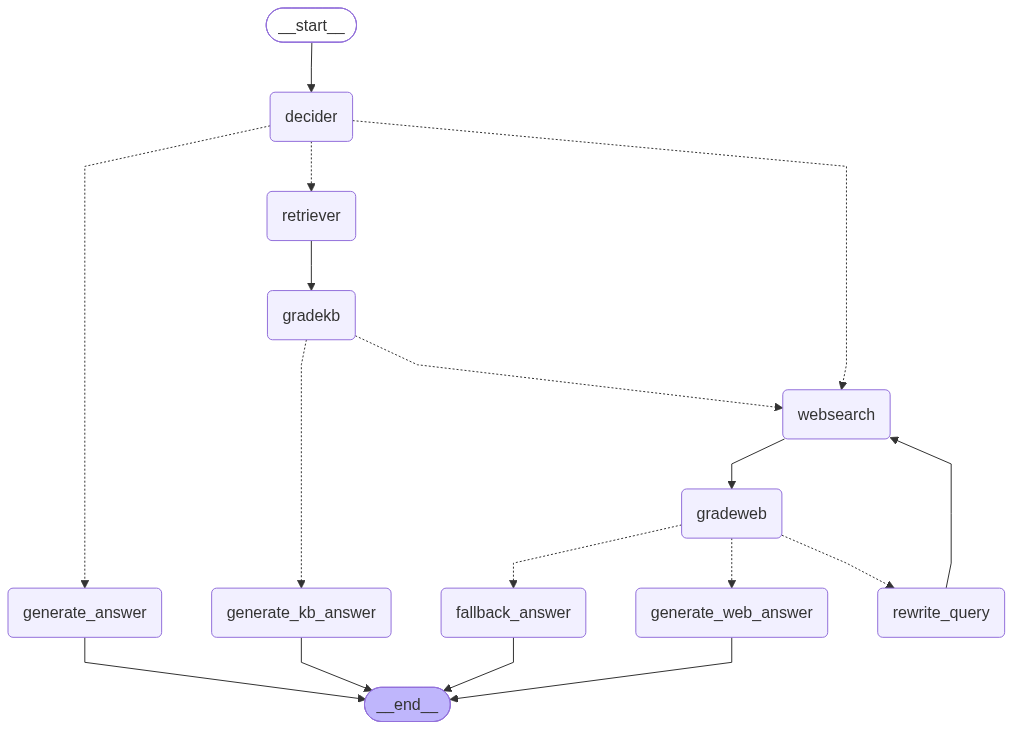

In [266]:
from langgraph.graph import StateGraph, END, START

graph = StateGraph(AgentState)

graph.add_node("decider", decider_node)
graph.add_node("retriever", retriever_node)
graph.add_node("gradekb", gradekb_node)
graph.add_node("generate_kb_answer", generate_kb_answer_node)

graph.add_node("websearch", websearch_node)
graph.add_node("gradeweb", grade_web_answer_node)
graph.add_node("generate_web_answer", generate_web_answer_node)
graph.add_node("rewrite_query", rewrite_query_node)
graph.add_node("fallback_answer", fallback_answer_node)

graph.add_node("generate_answer", generate_answer_node)

graph.add_edge(START, "decider")
graph.add_conditional_edges("decider", decider_router, {"retriever": "retriever", "generate_answer": "generate_answer", "websearch": "websearch"})
graph.add_edge("retriever", "gradekb")
graph.add_conditional_edges("gradekb", grade_kb_router, {"generate_kb_answer": "generate_kb_answer", "websearch": "websearch"})
graph.add_edge("generate_kb_answer", END)
graph.add_edge("websearch", "gradeweb")
graph.add_conditional_edges("gradeweb", grade_web_router, {"generate_web_answer": "generate_web_answer", "rewrite_query": "rewrite_query", "fallback_answer": "fallback_answer"})
graph.add_edge("rewrite_query", "websearch")
graph.add_edge("generate_web_answer", END)
graph.add_edge("fallback_answer", END)
graph.add_edge("generate_answer", END)

app = graph.compile()
app

In [267]:
res = app.invoke({"question": "What value is used for chunk_overlap?"})

Decider result: retriever

the documents were enough to answer the question
KB answer generated



In [268]:
res

{'question': 'What value is used for chunk_overlap?',
 'route': 'retriever',
 'context': [Document(id='0d35af74-2dad-43db-bba1-3c0b61743abb', metadata={'description': 'Build a custom retrieval agent with LangGraph that decides when to search a vector store or respond directly.', 'language': 'en', 'source': 'https://docs.langchain.com/oss/python/langgraph/agentic-rag#build-a-custom-rag-agent-with-langgraph', 'title': 'Build a custom RAG agent with LangGraph - Docs by LangChain'}, page_content='}\n                ],\n            },\n            {"role": "tool", "content": "meow", "tool_call_id": "1"},\n        ]\n    )\n}'),
  Document(id='678a6f0b-bdbe-4a01-931a-8087f12c2af6', metadata={'description': 'Build a custom retrieval agent with LangGraph that decides when to search a vector store or respond directly.', 'language': 'en', 'source': 'https://docs.langchain.com/oss/python/langgraph/agentic-rag#build-a-custom-rag-agent-with-langgraph', 'title': 'Build a custom RAG agent with LangGr